## Распознавание рукописных цифр MNIST: гистограммы градиентов и метод опорных векторов

Данные контеста Digit Recognizer: 42 000 размеченных картинок 28x28 в оттенках серого
и 28 000 тестовых без меток. Метки тестовых картинок есть только у Kaggle, поэтому
качество до отправки оценивается на отложенной части обучающей выборки, а итоговая
accuracy берется из результата на Kaggle.

Признаки - гистограммы направленных градиентов (**HOG**), классификатор выбирается
из четырех моделей по accuracy на отложенной выборке

### Задача 1. Данные и отложенная выборка

Каждая строка файла - 784 яркости пикселей, развернутые из квадрата 28x28 в строку.
Проверим, что данные целые, посмотрим на баланс цифр и на сами картинки, а затем
отложим пятую часть обучающей выборки для выбора модели

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import binomtest
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

y = train['label'].values
# строку из 784 пикселей сворачиваем обратно в картинку 28x28
X_img = train.drop(columns='label').values.reshape(-1, 28, 28).astype(np.float32)
test_img = test.values.reshape(-1, 28, 28).astype(np.float32)

print('обучающая:', X_img.shape, '| тестовая:', test_img.shape)
print('пропусков:', train.isna().sum().sum() + test.isna().sum().sum())
print('яркость пикселей: от', int(X_img.min()), 'до', int(X_img.max()))

обучающая: (42000, 28, 28) | тестовая: (28000, 28, 28)
пропусков: 0
яркость пикселей: от 0 до 255


Доля каждой цифры, %:
0     9.84
1    11.15
2     9.95
3    10.36
4     9.70
5     9.04
6     9.85
7    10.48
8     9.67
9     9.97


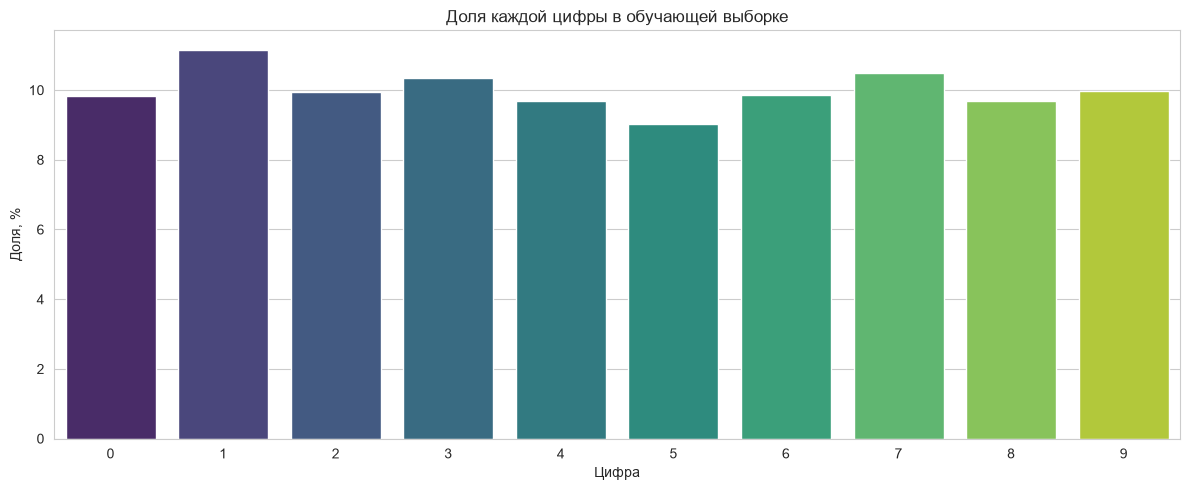

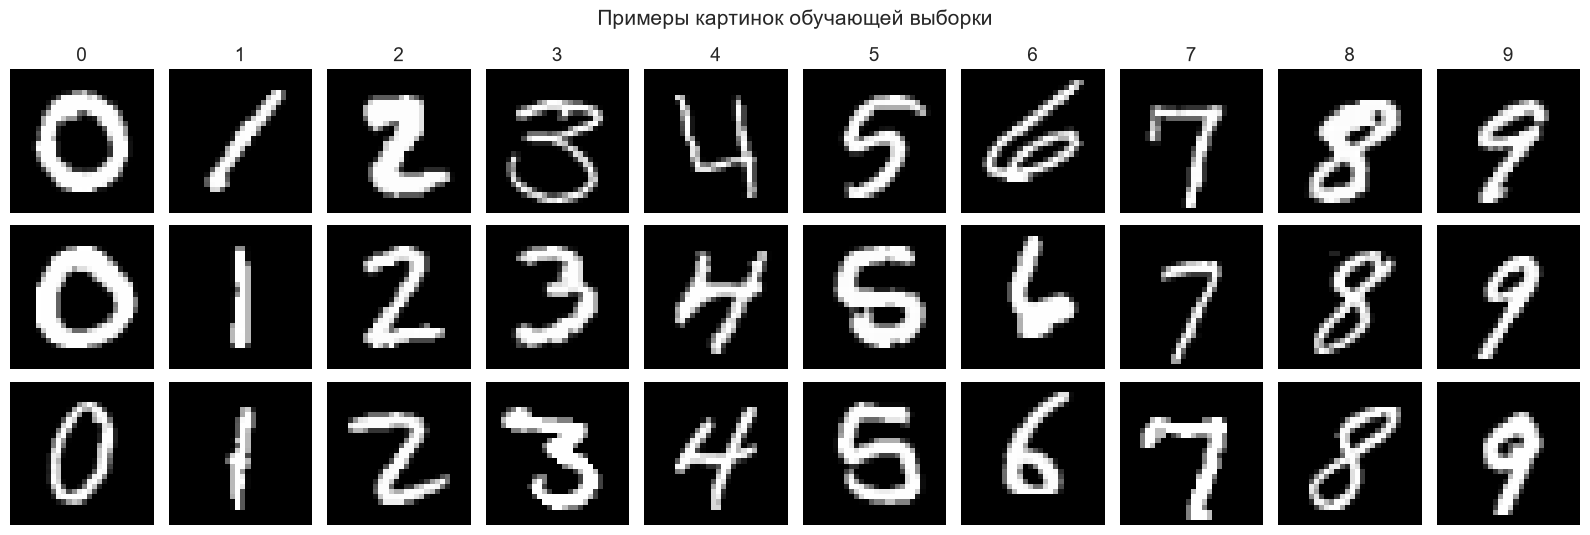

In [2]:
доли = pd.Series(y).value_counts(normalize=True).sort_index() * 100
print('Доля каждой цифры, %:')
print(доли.round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=доли.index, y=доли.values, palette='viridis', ax=ax)
ax.set_title('Доля каждой цифры в обучающей выборке')
ax.set_xlabel('Цифра')
ax.set_ylabel('Доля, %')
plt.tight_layout()
plt.show()

# по три первых примера каждой цифры: видно, насколько по-разному их пишут
fig, axes = plt.subplots(3, 10, figsize=(16, 5.5))
for цифра in range(10):
    for строка, i in enumerate(np.where(y == цифра)[0][:3]):
        axes[строка, цифра].imshow(X_img[i], cmap='gray')
        axes[строка, цифра].axis('off')
    axes[0, цифра].set_title(str(цифра), fontsize=14)
fig.suptitle('Примеры картинок обучающей выборки', fontsize=15)
plt.tight_layout()
plt.show()

In [3]:
# отложенная выборка отделяется до любого обучаемого шага,
# stratify сохраняет в обеих частях те же доли цифр
X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_img, y, test_size=0.2, stratify=y, random_state=42)

print('обучение:', len(y_train), '| отложенная:', len(y_val))
print('наибольшее расхождение долей цифр, п.п.:',
      round(np.abs(np.bincount(y_train) / len(y_train)
                   - np.bincount(y_val) / len(y_val)).max() * 100, 3))

обучение: 33600 | отложенная: 8400
наибольшее расхождение долей цифр, п.п.: 0.009


**Вывод по Задаче 1:** Данные целые, пропусков нет: 42 000 обучающих и 28 000 тестовых картинок,
яркость от 0 до 255. Классы почти равны - от 9.04% у пятерки до 11.15% у единицы,
поэтому **accuracy** здесь честная метрика: модель не наберет ее, угадывая одну
частую цифру.

По примерам видно, как по-разному пишут одну и ту же цифру: толщина линии, наклон,
открытая и закрытая четверка, семерка с засечкой и без. Отложенная
выборка - 8 400 картинок, доли цифр в ней расходятся с обучающей не больше чем
на 0.009 п.п

### Задача 2. Признаки HOG

В шаблоне к заданию гистограмма направлений градиента считается по всей картинке
сразу, и из нее не видно, в какой части цифры штрих идет вертикально, а в какой
горизонтально. **HOG** считает такую гистограмму в каждой клетке отдельно, поэтому
в признаках остается и направление штриха, и его место.

Клетка 7x7 пикселей делит картинку на сетку 4x4. Направлений 9, гистограммы нормируются
по блокам 2x2 клетки, чтобы толщина и нажим пера меньше влияли на признаки

In [4]:
параметры_hog = dict(orientations=9, pixels_per_cell=(7, 7),
                     cells_per_block=(2, 2), block_norm='L2-Hys')


def признаки_hog(картинки):
    # HOG ничего не обучает: каждая картинка переводится в вектор сама по себе,
    # поэтому одной и той же функцией обрабатываются все три выборки
    return np.array([hog(img, **параметры_hog) for img in картинки], dtype=np.float32)


X_train_hog = признаки_hog(X_train_img)
X_val_hog = признаки_hog(X_val_img)
test_hog = признаки_hog(test_img)

# блок 2x2 клетки сдвигается по сетке 4x4 на одну клетку - блоков 3x3,
# в каждом 4 клетки по 9 направлений
print('длина вектора HOG:', X_train_hog.shape[1], '| по расчету:', 3 * 3 * 4 * 9)
print('было признаков-пикселей:', 28 * 28)

длина вектора HOG: 324 | по расчету: 324
было признаков-пикселей: 784


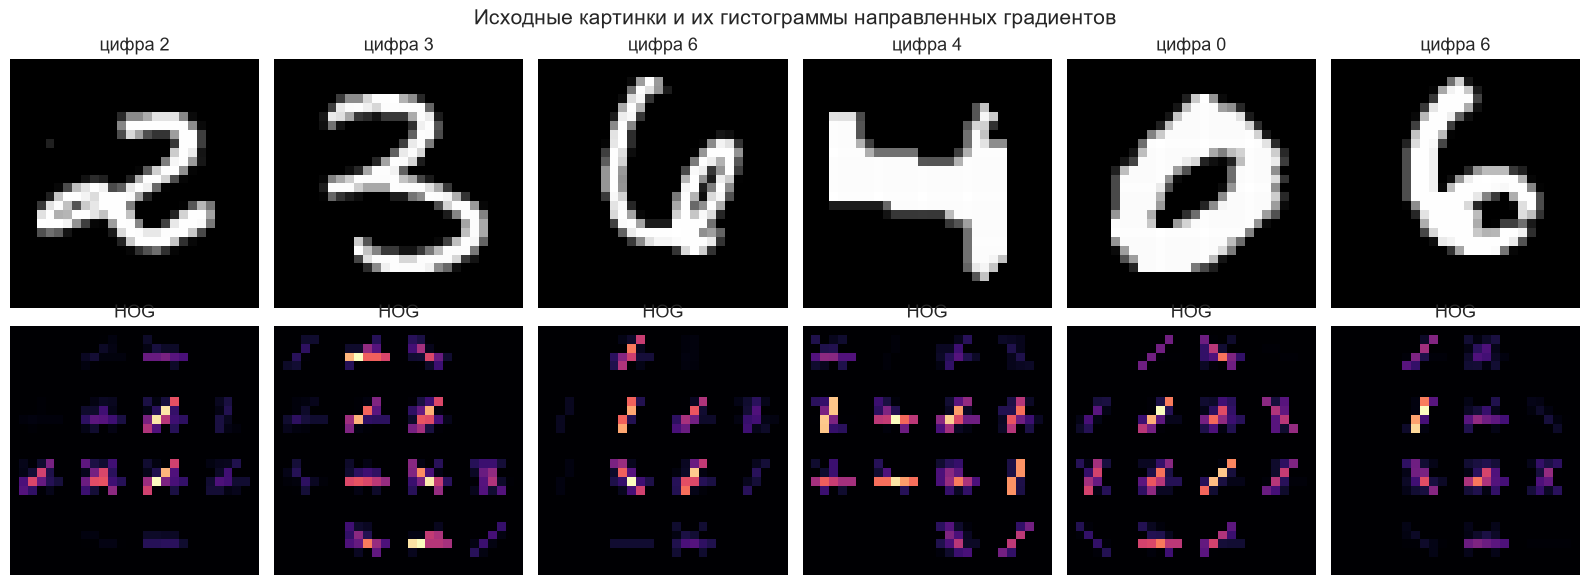

In [5]:
# картинка HOG: в каждой клетке нарисованы направления, длина штриха - вес направления
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for k, i in enumerate(range(6)):
    _, картинка_hog = hog(X_train_img[i], visualize=True, **параметры_hog)
    axes[0, k].imshow(X_train_img[i], cmap='gray')
    axes[0, k].set_title(f'цифра {y_train[i]}', fontsize=13)
    axes[1, k].imshow(картинка_hog, cmap='magma')
    axes[1, k].set_title('HOG', fontsize=13)
    for ax in axes[:, k]:
        ax.axis('off')
fig.suptitle('Исходные картинки и их гистограммы направленных градиентов', fontsize=15)
plt.tight_layout()
plt.show()

**Вывод по Задаче 2:** каждая картинка превратилась из 784 пикселей в вектор из **324** признаков,
и длина совпала с расчетом (3x3 блока по 4 клетки и 9 направлений), то есть
параметры сработали так, как задумано.

На картинках HOG видна форма цифры:
у нуля направления идут по кругу вокруг пустого центра, у четверки в середине
сетки стоят горизонтальная перекладина и вертикальные штрихи по бокам

### Задача 3. Выбор классификатора

Сравниваются четыре модели разного устройства, все с параметрами по умолчанию:
**ближайший центроид** (классификатор из шаблона, только на новых признаках),
**логистическая регрессия** (линейная граница), **k ближайших соседей** и
**SVC** с ядром rbf (нелинейная граница). Логистической регрессии признаки
масштабируются - масштаб обучается только на `X_train_hog`

In [6]:
модели = {
    'Ближайший центроид': NearestCentroid(),
    'Логистическая регрессия': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'k ближайших соседей': KNeighborsClassifier(),
    'SVC, ядро rbf': SVC(),
}

предсказания_val = {}
for имя, модель in модели.items():
    модель.fit(X_train_hog, y_train)
    предсказания_val[имя] = модель.predict(X_val_hog)

таблица = pd.DataFrame({
    'модель': list(предсказания_val),
    'accuracy': [accuracy_score(y_val, p) for p in предсказания_val.values()],
    'ошибок из 8400': [int((p != y_val).sum()) for p in предсказания_val.values()],
}).sort_values('accuracy', ascending=False).reset_index(drop=True)
таблица['accuracy'] = таблица['accuracy'].round(4)
таблица

,модель,accuracy,ошибок из 8400
0,"SVC, ядро rbf",0.9810,160
1,k ближайших соседей,0.9670,277
2,Логистическая регрессия,0.9639,303
3,Ближайший центроид,0.8989,849


Две лучшие модели проверялись на одних и тех же картинках, поэтому их можно сравнить
парно. Значение имеют только картинки, где одна модель права, а другая нет: если бы
модели были равны по качеству, такие случаи делились бы между ними поровну

In [7]:
первая, вторая = таблица.loc[0, 'модель'], таблица.loc[1, 'модель']
верно_1 = предсказания_val[первая] == y_val
верно_2 = предсказания_val[вторая] == y_val
только_1 = int((верно_1 & ~верно_2).sum())
только_2 = int((~верно_1 & верно_2).sum())

print(f'права только {первая}: {только_1}')
print(f'права только {вторая}: {только_2}')
# критерий Макнемара в точной форме - биномиальный тест на эти два числа
print('p-value:', binomtest(только_1, только_1 + только_2).pvalue)

права только SVC, ядро rbf: 168
права только k ближайших соседей: 51
p-value: 8.966794365295501e-16


**Вывод по Задаче 3:** лучшая модель - **SVC с ядром rbf**: accuracy **0.9810** на отложенной
выборке, 160 ошибок из 8 400. k ближайших соседей (0.9670) и логистическая
регрессия (0.9639) ошибаются в 1.7-1.9 раза чаще. Ближайший центроид дает 0.8989 -
это классификатор из шаблона, где на Kaggle было 0.417 с 16 столбцами общей
гистограммы. Выборки разные, но разница
больше чем вдвое, и дают ее признаки: классификатор тот же.

Разница между SVC и kNN не шум: из 219 картинок, где модели разошлись, права
SVC в 168, kNN - в 51, p-value порядка 1e-15

### Задача 4. Ошибки лучшей модели

Посмотрим, какие цифры модель путает между собой и как выглядят картинки,
на которых она ошибается

модель: SVC, ядро rbf
              precision    recall  f1-score   support

           0     0.9821    0.9927    0.9874       827
           1     0.9904    0.9915    0.9909       937
           2     0.9786    0.9856    0.9821       835
           3     0.9825    0.9667    0.9745       870
           4     0.9900    0.9779    0.9839       814
           5     0.9866    0.9736    0.9801       759
           6     0.9880    0.9952    0.9916       827
           7     0.9773    0.9795    0.9784       880
           8     0.9778    0.9729    0.9753       813
           9     0.9566    0.9726    0.9645       838

    accuracy                         0.9810      8400
   macro avg     0.9810    0.9808    0.9809      8400
weighted avg     0.9810    0.9810    0.9810      8400



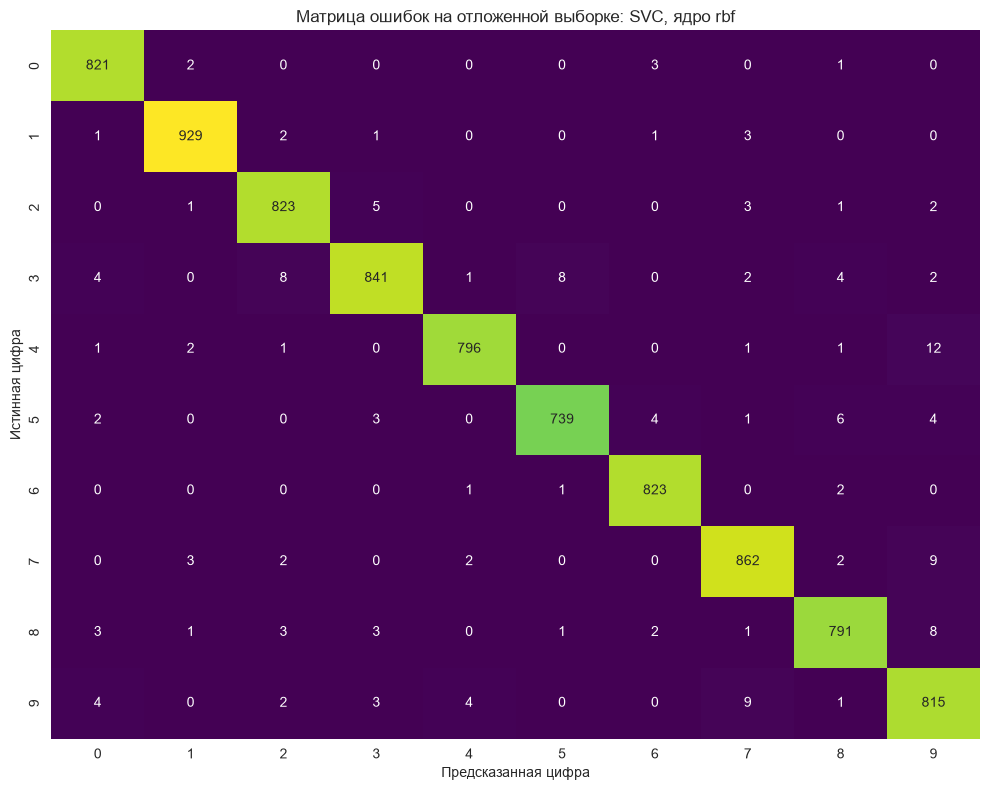

4 -> 9: 12
9 -> 7: 9
7 -> 9: 9
8 -> 9: 8
3 -> 5: 8


In [8]:
лучшая = таблица.loc[0, 'модель']
pred_val = предсказания_val[лучшая]
print('модель:', лучшая)
print(classification_report(y_val, pred_val, digits=4))

матрица = confusion_matrix(y_val, pred_val)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(матрица, annot=True, fmt='d', cmap='viridis', cbar=False, ax=ax)
ax.set_title(f'Матрица ошибок на отложенной выборке: {лучшая}')
ax.set_xlabel('Предсказанная цифра')
ax.set_ylabel('Истинная цифра')
plt.tight_layout()
plt.show()

# самые частые пары «истинная -> предсказанная» вне диагонали
пары = [(матрица[i, j], i, j) for i in range(10) for j in range(10) if i != j]
for n, i, j in sorted(пары, reverse=True)[:5]:
    print(f'{i} -> {j}: {n}')

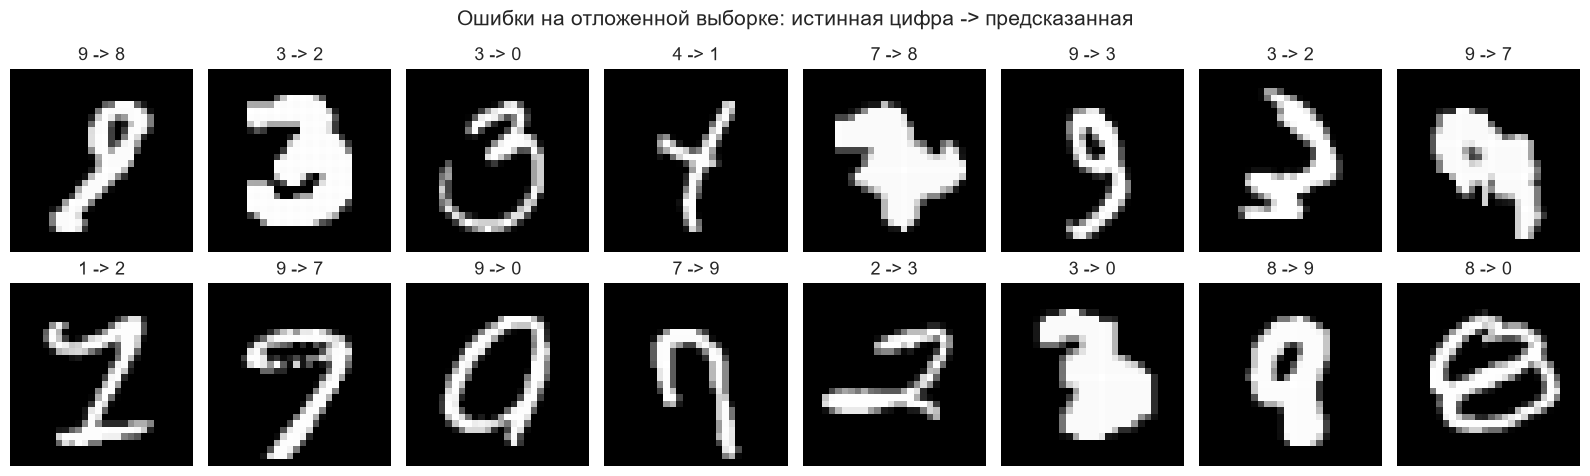

In [9]:
ошибки = np.where(pred_val != y_val)[0]
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for ax, i in zip(axes.ravel(), ошибки[:16]):
    ax.imshow(X_val_img[i], cmap='gray')
    ax.set_title(f'{y_val[i]} -> {pred_val[i]}', fontsize=13)
    ax.axis('off')
fig.suptitle('Ошибки на отложенной выборке: истинная цифра -> предсказанная', fontsize=15)
plt.tight_layout()
plt.show()

**Вывод по Задаче 4:** у модели нет слабой цифры: f1 по всем классам от 0.9645 до 0.9916.
Меньше всего полнота у тройки (0.9667), меньше всего точность у девятки (0.9566),
и девятка стоит в четырех из пяти самых частых ошибок: 4 -> 9 (12 раз),
9 -> 7 и 7 -> 9 (по 9), 8 -> 9 (8).

Среди 16 показанных ошибок есть картинки, которые и человек прочитает неуверенно:
девятка с замкнутым хвостом похожа на восьмерку, семерка и тройка залиты в сплошное
пятно. Но есть и явные промахи: четкая девятка названа тройкой, тройка из тонкой
линии - нулем

### Задача 5. Предсказание для Kaggle

Для отправки лучшая модель обучается заново на всех 42 000 картинках: параметры
те же, а данных больше

In [10]:
X_all_hog = np.vstack([X_train_hog, X_val_hog])
y_all = np.concatenate([y_train, y_val])

финальная = модели[лучшая]
финальная.fit(X_all_hog, y_all)
pred_test = финальная.predict(test_hog)

submission = pd.DataFrame({'ImageId': np.arange(1, len(pred_test) + 1), 'Label': pred_test})
submission.to_csv('submission.csv', index=False)
print('строк в файле:', len(submission))
print(submission.head().to_string(index=False))

# если модель где-то сломалась, доли предсказанных цифр разойдутся с обучающими
сверка = pd.DataFrame({
    'в обучении, %': (pd.Series(y_all).value_counts(normalize=True).sort_index() * 100).round(2),
    'в предсказании, %': (pd.Series(pred_test).value_counts(normalize=True).sort_index() * 100).round(2),
})
print()
print(сверка.to_string())

строк в файле: 28000
 ImageId  Label
       1      2
       2      0
       3      9
       4      9
       5      3

   в обучении, %  в предсказании, %
0           9.84               9.96
1          11.15              11.41
2           9.95              10.12
3          10.36               9.89
4           9.70               9.80
5           9.04               8.99
6           9.85               9.79
7          10.48              10.36
8           9.67               9.78
9           9.97               9.91


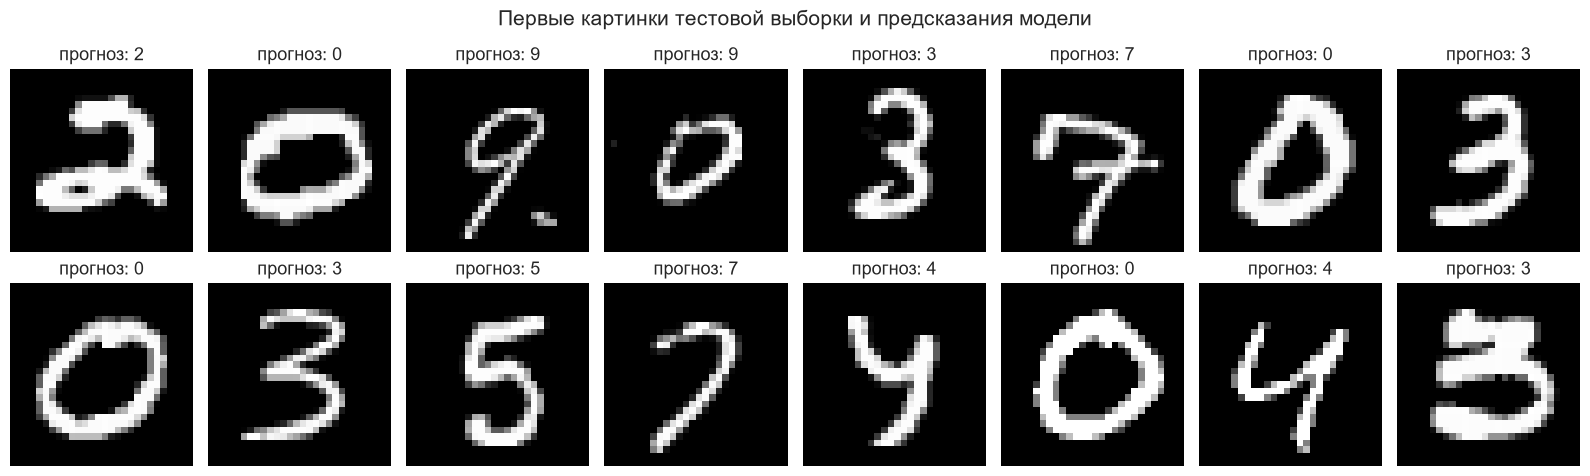

In [11]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(test_img[i], cmap='gray')
    ax.set_title(f'прогноз: {pred_test[i]}', fontsize=13)
    ax.axis('off')
fig.suptitle('Первые картинки тестовой выборки и предсказания модели', fontsize=15)
plt.tight_layout()
plt.show()

**Вывод по Задаче 5:** файл `submission.csv` содержит 28 000 строк в формате контеста. Доли
предсказанных цифр совпадают с обучающими с точностью до 0.47 п.п. (у тройки
10.36% против 9.89%), то есть модель не сваливает ответы в один класс. На 15 из 16
первых тестовых картинок прогноз совпадает с тем, что видно глазом; четвертая
похожа на маленький нуль, а модель назвала ее девяткой.

Результат на Kaggle - accuracy **0.979**, порог задания 0.6 пройден с большим
запасом. Это почти столько же, сколько на отложенной выборке (0.981), то есть
оценка, по которой выбиралась модель, не завысила качество

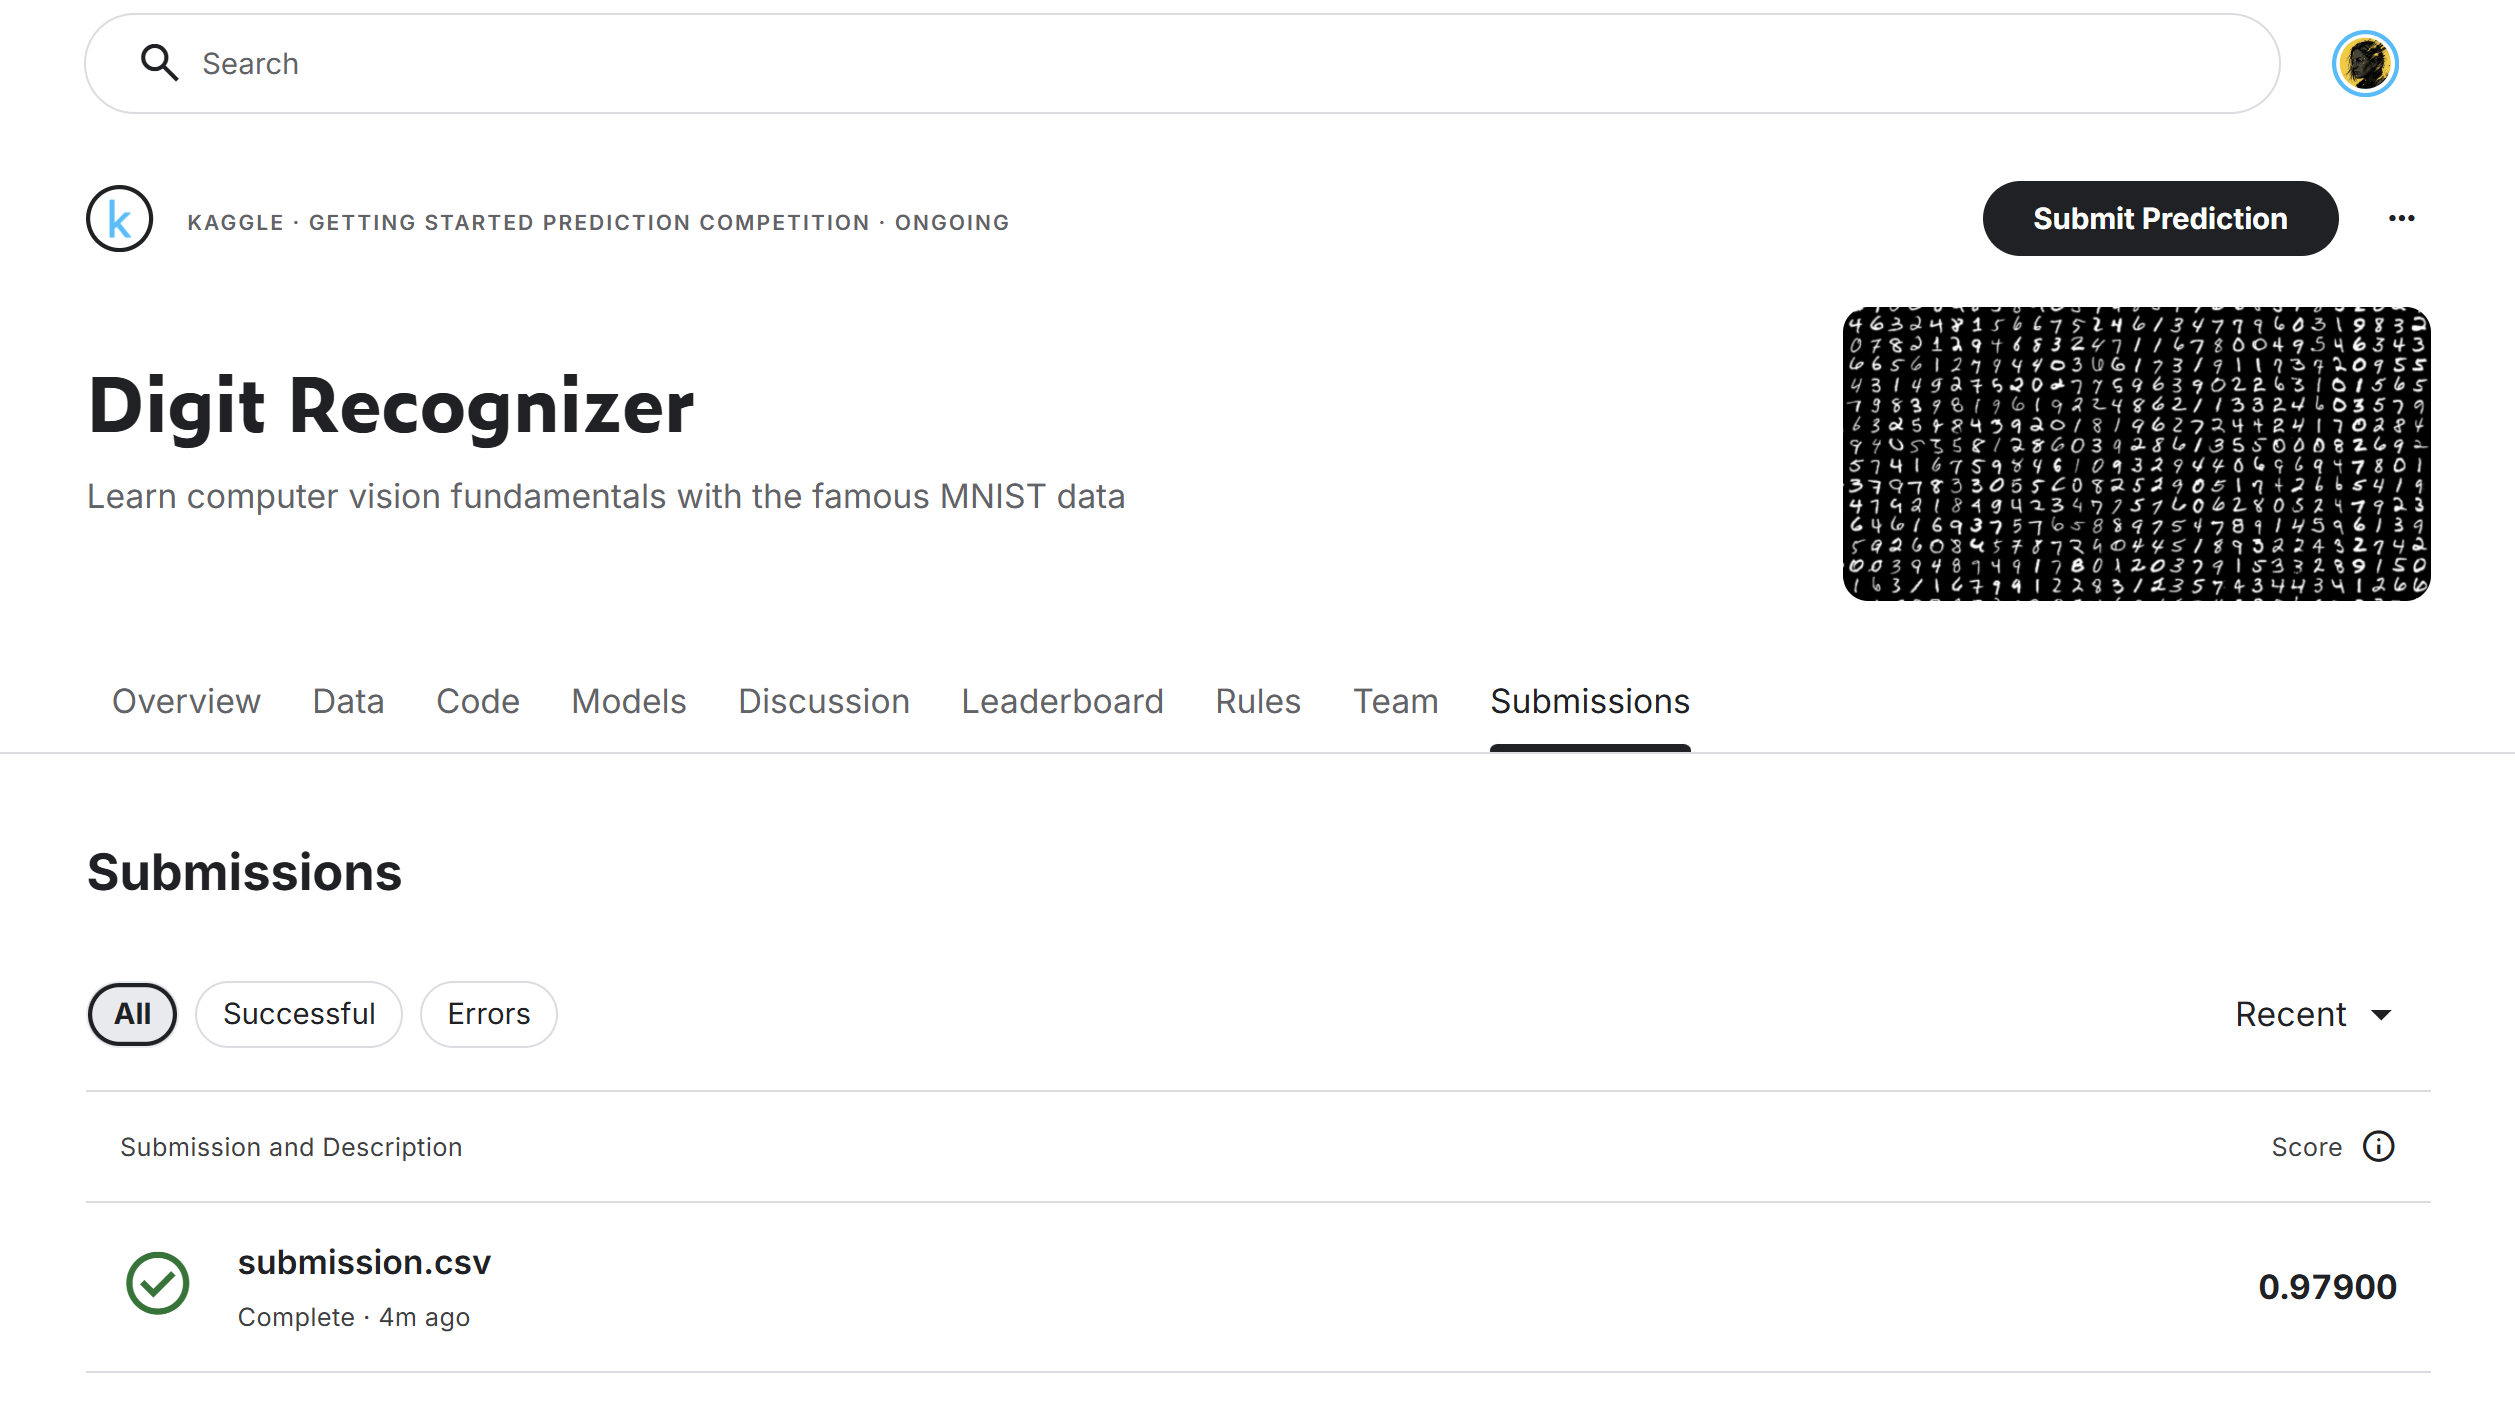